In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] =  os.getenv("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

### LangChain v1

### chat gpt

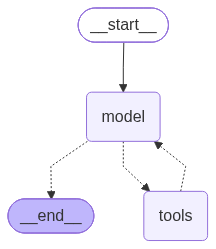

In [10]:
from langchain.agents import create_agent

def weather_report(city:str)-> str :
    """get the Weather for a city"""
    return f"The Weather in {city} is rainy."
    
agent = create_agent(
    model= 'gpt-5',
    tools=[weather_report],
    system_prompt="you are a weather report chatbot.",
    
)

agent

In [ ]:
# agent.invoke({"messages":[{"role":"user","content":"What is the weather in New York?"}]})
# agent.invoke({"messages":"What is the weather in New York?"})

In [42]:
from langchain_openai import ChatOpenAI

open_ai_model = ChatOpenAI(
    model='gpt-5'
)
open_ai_model

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14', 'langchain-openai': '1.4.1'}}, output_version=None, profile={'name': 'GPT-5', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['none', 'low', 'medium', 'high', 'xhigh']}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001EA539156F0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions

In [43]:
# open_ai_model.invoke("Explain AI") # does not give free tier 

#### gemini

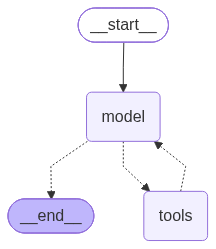

In [40]:
# gemini
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny and 75°F."
    
google_agent = create_agent(
    model="google_genai:gemini-3.6-flash", 
    tools=[get_weather],
    system_prompt= "You are a helpful assistant."
)
google_agent

In [41]:
google_agent.invoke({"messages":"What is the weather of New York city?"})

{'messages': [HumanMessage(content='What is the weather of New York city?', additional_kwargs={}, response_metadata={}, id='cac99a11-c37f-43d8-925e-45abf9078d22'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'Ywhx1Fih': 'EqcCCqQCARFNMg8XAmPuevvm7eLp5cGeTCvq1B/uGj6ZkXly6Wnq/QUvUoGEtzsdupaK/3NqC4zEA3VspM0VA9YSIZJTSnjHI/SkNmipqOle0fuYBCoAMjm1AQo+sU2hbF61yOymCkditOR60IE1ZgsPwyev2NDr/TWNqpj0U5/igGskRN5MBkhY/a+se0pAnJqCLt02wDWQWp8wFxuvUPonxI+WjpHyniVVK9HomfTrfpAo/B0/GsGKGbhSiAOvb1yvsOHtAUM1XPsfBsVv4RaLatiQvdzlQJrmb7eh9mwR1/+IDDEQEdtSD2dSCurL6krG73KBz9r7PWY7wOg61qgby87Pg1T57wp1bZsTA7KR2B9OdbOAjkOm8H5wqWnra72KlAvL3BJzvw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f9581-b321-7121-bd13-ba2dde8fcdc1-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New Yo

In [48]:
response = google_agent.invoke({"messages":"What is the weather of New York city?"})
response["messages"][-1].content[0]['text']

'The current weather in New York City is sunny with a temperature of 75°F.'

In [38]:
from langchain_google_genai import ChatGoogleGenerativeAI

google_model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

google_model

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.1'}}, output_version=None, profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'medium'}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.6-flash', temperature=None, client=<google.genai.client.Client object at 0x000001EA53923430>, defau

In [39]:
google_model.invoke("Explain AI.")

AIMessage(content=[{'type': 'text', 'text': 'At its simplest, **Artificial Intelligence (AI)** is the science of making computers and machines smart enough to perform tasks that typically require human intelligence. \n\nThese tasks include things like understanding language, recognizing patterns, learning from experience, making decisions, and solving complex problems.\n\nHere is a breakdown of how AI works, the different types, everyday examples, and why it matters.\n\n---\n\n### 1. How Does AI Work?\nUnlike traditional software, which follows strict, hard-coded rules ("if the user clicks X, do Y"), AI systems **learn from data**. \n\n1. **Feeding Data:** An AI is given massive amounts of data (text, images, numbers, or audio).\n2. **Finding Patterns:** The AI analyzes this data to find patterns and relationships. For example, by looking at millions of photos labeled "cat" and "dog," it learns the tiny visual differences between the two.\n3. **Making Predictions:** When given *new* da

In [51]:
google_response = google_model.invoke("Explain AI.")
print(google_response.content[0]['text'])

At its simplest, **Artificial Intelligence (AI)** refers to computer systems or machines that can perform tasks that typically require human intelligence. These tasks include things like learning from experience, recognizing patterns, understanding language, solving complex problems, and making decisions.

Instead of being explicitly programmed with rules for every single situation, modern AI systems look at vast amounts of data, find patterns, and figure out how to solve problems on their own.

---

### How Does AI Work?

Think of AI like a child learning about the world. If you show a child thousands of pictures of cats and dogs and point out which is which, the child eventually learns the subtle differences (whiskers, snout shape, ears) and can recognize a cat they’ve never seen before. 

AI works similarly using three core concepts:

1. **Data:** The "food" AI eats. This can be text, images, numbers, audio, or video.
2. **Algorithms:** The rules or math equations the computer uses 

#### Groq

In [53]:
from langchain_groq import ChatGroq

# Set your free Groq API key
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Initialize the model (using a free model like Llama 3)
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7
)

# Use it normally within your chains
response = llm.invoke("Explain AI in simple worlds?")
print(response.content)

**What is AI?**

AI, or Artificial Intelligence, is a computer system that can think and learn like a human. It's like a super-smart robot that can help us with tasks, answer questions, and even make decisions.

**How does it work?**

AI uses special algorithms (like recipes) to look at data (like information) and learn from it. This helps the AI system to:

1. **Understand**: Recognize patterns and meanings in data.
2. **Learn**: Improve its performance and make better decisions over time.
3. **Act**: Take actions based on what it has learned.

**Examples of AI**

1. Virtual assistants like Siri, Google Assistant, or Alexa.
2. Image recognition (like Facebook tagging faces).
3. Self-driving cars.
4. Chatbots (like this one!) that can have conversations with you.

**In simple words**, AI is a computer system that can think, learn, and act like a human, making our lives easier and more efficient!
